<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_modeling_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [17]:
# Modeling
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.2), 
                              padding = 'same', input_shape=(224, 224, 1)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.2), 
                              padding = 'same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1000, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [3]:
train_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled'
train_path_list = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_set_part_path = os.path.join(dirname, filename)
            train_path_list.append(train_set_part_path)

train_path_list.sort()

In [4]:
train_target_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part'
train_target_path_list = []

for dirname, _, filenames in os.walk(train_target_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_target_part_path = os.path.join(dirname, filename)
            train_target_path_list.append(train_target_part_path)
        
train_target_path_list.sort()

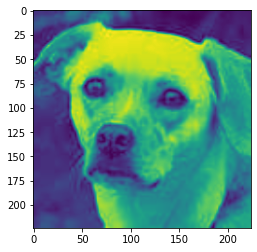

1


In [5]:
a = np.load(train_path_list[0], allow_pickle=True)
b = np.load(train_target_path_list[0], allow_pickle=True)

plt.imshow(a[6])
plt.show()
print(b[6])

In [6]:
train_set = []
train_target = []

for i in range(0, 4):
    a = np.load(train_path_list[i], allow_pickle=True)
    b = np.load(train_target_path_list[i], allow_pickle=True)

    print(len(a), len(b), sep=' ', end='\n')
    print(train_path_list[i], train_target_path_list[i])
    print(a.shape, b.shape)

    for x in a:
        train_set.append(x/255.0)
    for y in b:
        train_target.append(y)

    del a
    del b

train_set = np.array(train_set)
train_target = np.array(train_target)

print(train_set.shape)
print(type(train_set[0][0][0]))

2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_1.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_1.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_2.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_2.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_3.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_3.npy
(2000, 224, 224) (2000,)
2005 2005
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_4.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_4.npy
(2005, 224, 224) (2005,)
(8005, 224, 224)
<class 'numpy.float64'>


In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [8]:
def model_fit(train_set_, train_target_):
    # train_set, validation_set 분리
    x_train, x_val, y_train, y_val = train_test_split(
        train_set_, train_target_, test_size=0.2, random_state=42
    )

    # Training
    hist = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
               callbacks=[early_stopping_cb], batch_size = 64)

    return hist

In [19]:
history = []
history.append(model_fit(train_set, train_target))

Epoch 1/20
101/101 [==============================] - 15s 146ms/step - loss: 4.4197 - accuracy: 0.5186 - val_loss: 1.9088 - val_accuracy: 0.5809
Epoch 2/20
101/101 [==============================] - 14s 139ms/step - loss: 1.4884 - accuracy: 0.5556 - val_loss: 1.1750 - val_accuracy: 0.5759
Epoch 3/20
101/101 [==============================] - 14s 138ms/step - loss: 1.0135 - accuracy: 0.5924 - val_loss: 1.0646 - val_accuracy: 0.5272
Epoch 4/20
101/101 [==============================] - 14s 137ms/step - loss: 0.8356 - accuracy: 0.6098 - val_loss: 0.7802 - val_accuracy: 0.5984
Epoch 5/20
101/101 [==============================] - 14s 137ms/step - loss: 0.7469 - accuracy: 0.6171 - val_loss: 0.7290 - val_accuracy: 0.5984
Epoch 6/20
101/101 [==============================] - 14s 137ms/step - loss: 0.7029 - accuracy: 0.6220 - val_loss: 0.6956 - val_accuracy: 0.6190
Epoch 7/20
101/101 [==============================] - 14s 136ms/step - loss: 0.6769 - accuracy: 0.6324 - val_loss: 0.6885 - val_ac

In [10]:
def show_graph(history_):
    accuracy = history_.history['accuracy']
    val_accuracy = history_.history['val_accuracy']
    loss = history_.history['loss']
    val_loss = history_.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 2))

    plt.subplot(121)
    plt.ylim(0, 1.1)
    plt.subplots_adjust(top=2)
    plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Trainging and validation accuracy and loss')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy and Loss')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
              fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, -0.1))

    plt.subplot(122)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, 0))

    plt.show()

reference
https://chealin93.tistory.com/69

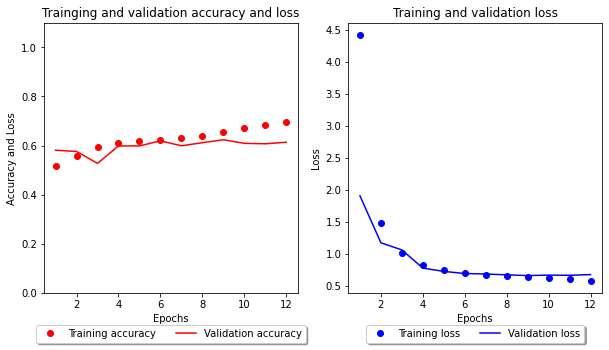

In [20]:
for x in history:
    show_graph(x)

In [12]:
# Load Test Set

test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/test_set_scaled/test_scaled.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

In [21]:
test_set_scaled = test_set / 255.0

model.evaluate(test_set_scaled, test_target)

64/64 [==============================] - 1s 22ms/step - loss: 0.6659 - accuracy: 0.6164


[0.6658907532691956, 0.6164112687110901]

(1, 224, 224, 1)


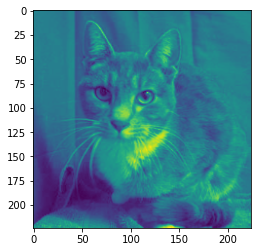

In [14]:
sample = test_set[58] / 255.0
sample = sample.reshape(1, 224, 224, 1)
print(sample.shape)
plt.imshow(test_set[58])
plt.show()

In [15]:
def print_predict(sample_):
    result = model.predict(sample)
    result = result[0][0]
    

    print('RESULT: ', end='')
    if(result < 0.5):
        print('Cat')
    elif(result > 0.5):
        print('Dog')
    else:
        print('Can\'t know')

In [16]:
print_predict(sample)

1/1 [==============================] - 0s 81ms/step
RESULT: Cat
